# Curry Points Predictor (By Pranav Singh)

## Project Overview

This notebook uses an LSTM (Long Short-Term Memory) neural network to predict Stephen Curry's points in his next game based on his recent performance history.

### Research Question
Can we predict Stephen Curry's scoring performance in upcoming games based on his recent game statistics?

### Features Used
- **pts**: Curry's points (target variable)
- **min**: Minutes played
- **fgm**: Field goals made
- **fg3m**: 3-pointers made

### Data Sources
- `curry_game_logs.csv`: Stephen Curry's game-by-game statistics (2013-2025)
- `opponent_matchup.csv`: Opponent team statistics
- `teammate_availability.csv`: Key teammate availability (Klay Thompson, Draymond Green, Kevin Durant)

---
# Data Pre-processing 

In [14]:

# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
torch.manual_seed(42);
# Calculate and print some evaluation metrics
from sklearn.metrics import mean_absolute_error, r2_score

In [15]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


In [16]:
#read in data

curry_game_logs = pd.read_csv("curry_game_logs.csv")
opponent_matchup = pd.read_csv("opponent_matchup.csv")
teammate_availability = pd.read_csv("teammate_availability.csv")

# Convert dates to datetime for merging
curry_game_logs['game_date'] = pd.to_datetime(curry_game_logs['game_date'])
opponent_matchup['game_date'] = pd.to_datetime(opponent_matchup['game_date'])
teammate_availability['game_date'] = pd.to_datetime(teammate_availability['game_date'])

# Merge all dataframes
merged_data = curry_game_logs.merge(
    opponent_matchup, 
    on=['game_date', 'season'], 
    how='left', 
    suffixes=('', '_opp')
).merge(
    teammate_availability,
    on=['game_date', 'season'],
    how='left'
)

print(f"Total games after merging: {len(merged_data)}")
print(f"Features: {merged_data.columns.tolist()}")

Total games after merging: 789
Features: ['game_date', 'wl', 'min', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'pf', 'pts', 'plus_minus', 'season', 'opponent', 'home_away', 'opponent_opp', 'home_away_opp', 'opp_fg_pct', 'opp_fg3_pct', 'opp_ft_pct', 'opp_reb', 'opp_ast', 'opp_stl', 'opp_blk', 'opp_pts', 'opp_def_rating', 'opp_pace', 'opp_possessions', 'klay_played', 'draymond_played', 'durant_played', 'jimmy_played', 'key_teammates_missing']


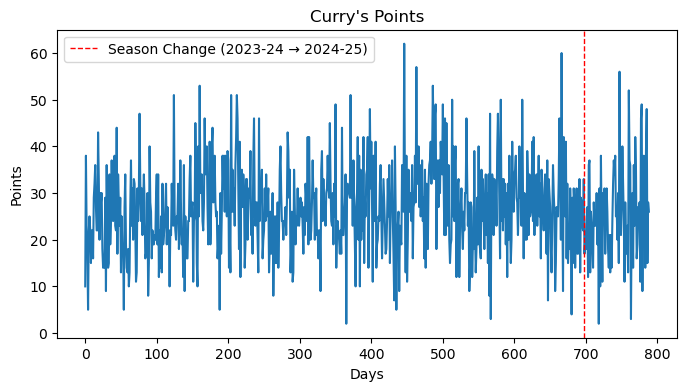

In [17]:
# plot currys points from previous games

fig = plt.figure(figsize=(8,4))
plt.plot(curry_game_logs['pts'])
# plt.plot(curry_game_logs['game_date'])

# Find where 2023-24 season ends and 2024-25 season starts
season_change_idx = curry_game_logs[curry_game_logs['season'] == '2023-24'].index[-1] + 0.5
plt.axvline(x=season_change_idx, color='red', linestyle='--', linewidth=1, label='Season Change (2023-24 → 2024-25)')

plt.title("Curry's Points")
plt.xlabel("Days")
plt.ylabel("Points")
plt.legend()
plt.show()

# this data shows the games curry has acutally played in, and doesnt show playoff games, just the regular seasons 23-24 and 24-25. 


## Feature Engineering and Sequence Preparation

We create sequences of `n_previous_days` games to predict the points for the next game. This sliding window approach allows the LSTM to learn patterns in Curry's recent performance.


In [18]:
# Prepare the training sequence with multiple features

n_previous_days = 10
n_future_days = 1

# Sort by date to ensure chronological order
merged_data = merged_data.sort_values('game_date').reset_index(drop=True)

# Simple features
feature_cols = [
    'pts',  # Curry's points (main target)
    'min',  # Minutes played
    'fgm',  # Field goals made
    'fg3m',  # 3-pointers made
]

# Fill NaN values with 0 for opponent stats (if they're missing)
for col in feature_cols:
    if col in merged_data.columns:
        merged_data[col] = merged_data[col].fillna(0)
    else:
        merged_data[col] = 0

# Extract feature data
feature_data = merged_data[feature_cols].values.astype(np.float32)

# Normalize features (important for neural networks!)
scaler = StandardScaler()
feature_data_scaled = scaler.fit_transform(feature_data)

# Create sequences
X, y = [], []
for i in range(len(feature_data_scaled) - n_previous_days - n_future_days):
    # Use all features for the input sequence
    X.append(feature_data_scaled[i:i+n_previous_days])
    # Only predict points for the output (first column)
    y.append(feature_data_scaled[i+n_previous_days:i+n_previous_days+n_future_days, 0])

X = np.stack(X)
y = np.stack(y)

print(f"Input shape: {X.shape}")  # (samples, sequence_length, features)
print(f"Output shape: {y.shape}")  # (samples, future_days)
print(f"Number of features: {len(feature_cols)}")
print(f"Features used: {feature_cols}")


Input shape: (778, 10, 4)
Output shape: (778, 1)
Number of features: 4
Features used: ['pts', 'min', 'fgm', 'fg3m']


In [19]:
split = int(0.7 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test   = X[split:], y[split:]

In [20]:
# convert to tensors
X_train_tensor = torch.tensor(X_train).float()
X_test_tensor = torch.tensor(X_test).float()
y_train_tensor = torch.tensor(y_train).float()
y_test_tensor = torch.tensor(y_test).float()
print(f"Training input shape: {X_train_tensor.shape}")
print(f"Test input shape: {X_test_tensor.shape}")

# Larger batch for better generalization
batch_size = 32

# make a TensorDataset object for the training data
ds_train = TensorDataset(X_train_tensor, y_train_tensor)

# make a loader object for the training data
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True)

# make a TensorDataset object for the test data
ds_test = TensorDataset(X_test_tensor, y_test_tensor)

# make a loader object for the test data
test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

Training input shape: torch.Size([544, 10, 4])
Test input shape: torch.Size([234, 10, 4])


---
# Model Construction

## LSTM Architecture

We use a simple single-layer LSTM with dropout regularization to prevent overfitting. The architecture:
- **Input**: Sequences of 10 previous games with 4 features each
- **LSTM Layer**: 16 hidden units
- **Dropout**: 30% to prevent overfitting
- **Output**: Predicted points for the next game

The model is trained with:
- **Loss Function**: Huber Loss (robust to outliers)
- **Optimizer**: Adam with weight decay
- **Early Stopping**: Prevents overfitting by stopping when test loss stops improving

## Building LSTM Model


In [21]:
# Simple 1-layer LSTM with dropout
class EnhancedPointsLSTM(nn.Module):
    def __init__(self, n_future_days, input_size=4, hidden_size=16, num_layers=1):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, n_future_days)
        
    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        last = h_n[-1]
        last = self.dropout(last)
        output = self.fc(last)
        return output

## Training the RNN with the LSTM

In [22]:
# Initialize model with correct input size (number of features)
n_features = len(feature_cols)
model = EnhancedPointsLSTM(n_future_days=n_future_days, input_size=n_features).to(device)
print(f"Model initialized with {n_features} input features")
print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

Model initialized with 4 input features
Model parameters: 1425


Then, we define our loss funtion and our gradient descent algorithm"

In [23]:
# Huber loss
criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [24]:
EPOCHS = 100

# make empty arrays to keep track of the losses
train_losses = []
test_losses = []
best_test_loss = float('inf')
patience_counter = 0
early_stop_patience = 100  # Stop quickly when test loss increases

# Training loop with early stopping
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
        
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            test_loss += criterion(pred, yb).item() * xb.size(0)
            
    n_train, n_test = len(train_loader.dataset), len(test_loader.dataset)
    train_loss_avg = train_loss / n_train
    test_loss_avg = test_loss / n_test
    train_losses.append(train_loss_avg)
    test_losses.append(test_loss_avg)
    
    # Learning rate scheduling
    scheduler.step(test_loss_avg)
    
    # Early stopping
    if test_loss_avg < best_test_loss:
        best_test_loss = test_loss_avg
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train MSE: {train_loss_avg:.6f} | test MSE: {test_loss_avg:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    if patience_counter >= early_stop_patience:
        print(f"Early stopping at epoch {epoch}")
        # Load best model
        model.load_state_dict(torch.load('best_model.pth', weights_only=True))
        break

print(f"\nBest test loss: {best_test_loss:.6f}")


Epoch 001 | train MSE: 0.410509 | test MSE: 0.442842 | LR: 0.005000


Epoch 005 | train MSE: 0.400491 | test MSE: 0.447969 | LR: 0.005000
Epoch 010 | train MSE: 0.400084 | test MSE: 0.448660 | LR: 0.002500
Epoch 015 | train MSE: 0.398962 | test MSE: 0.449324 | LR: 0.001250
Epoch 020 | train MSE: 0.398761 | test MSE: 0.449203 | LR: 0.000625
Epoch 025 | train MSE: 0.395856 | test MSE: 0.449734 | LR: 0.000313
Epoch 030 | train MSE: 0.396097 | test MSE: 0.449859 | LR: 0.000313
Epoch 035 | train MSE: 0.396038 | test MSE: 0.450003 | LR: 0.000156
Epoch 040 | train MSE: 0.396005 | test MSE: 0.450052 | LR: 0.000078
Epoch 045 | train MSE: 0.397226 | test MSE: 0.450039 | LR: 0.000039
Epoch 050 | train MSE: 0.398028 | test MSE: 0.450027 | LR: 0.000020
Epoch 055 | train MSE: 0.397537 | test MSE: 0.450011 | LR: 0.000010
Epoch 060 | train MSE: 0.395805 | test MSE: 0.450001 | LR: 0.000010
Epoch 065 | train MSE: 0.398992 | test MSE: 0.450000 | LR: 0.000005
Epoch 070 | train MSE: 0.396109 | test MSE: 0.449996 | LR: 0.000002
Epoch 075 | train MSE: 0.396971 | test MSE: 0.44

---
# Analysis and Visualization

## Model Evaluation

Below we visualize the training process and evaluate the model's predictions:
- **Training vs Test Loss**: Shows how well the model learned without overfitting
- **Predicted vs Actual**: Scatter plot comparing predictions to actual points scored

Actuals shape: (234, 1), Predictions shape: (234, 1)


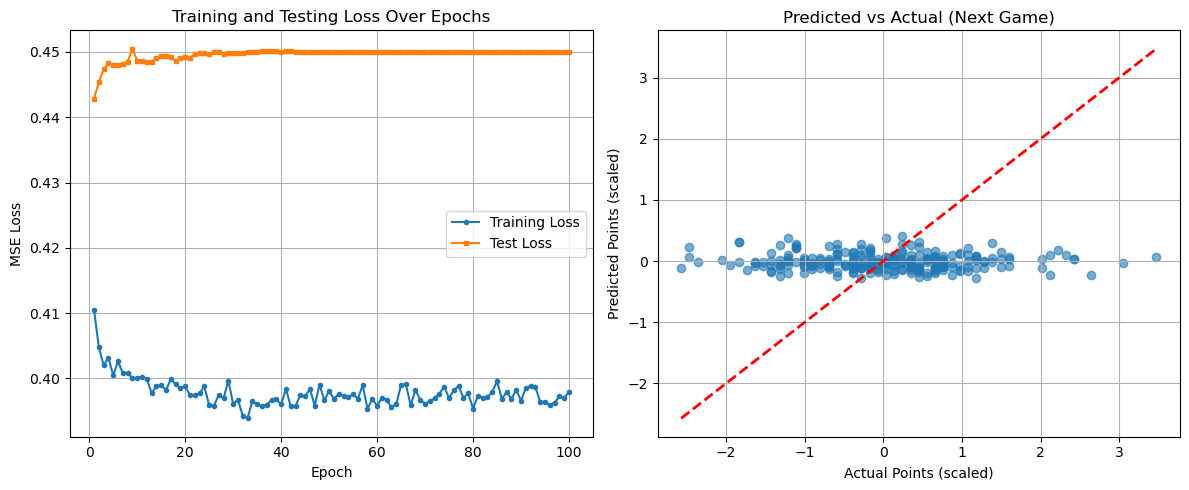


Model Evaluation Metrics:
Mean Absolute Error (scaled): 0.820914
R² Score: -0.030988
Final Training Loss: 0.397953
Final Test Loss: 0.449994
Best Test Loss: 0.442842


In [25]:
# Plot training and test losses
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
epochs_trained = len(train_losses)
plt.plot(range(1, epochs_trained + 1), train_losses, 'o-', label='Training Loss', markersize=3)
plt.plot(range(1, epochs_trained + 1), test_losses, 's-', label='Test Loss', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Testing Loss Over Epochs')
plt.legend()
plt.grid(True)

# Make predictions on test set and visualize
model.eval()
all_predictions = []
all_actuals = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        all_predictions.append(pred.cpu().numpy())
        all_actuals.append(yb.cpu().numpy())

all_predictions = np.concatenate(all_predictions, axis=0)
all_actuals = np.concatenate(all_actuals, axis=0)

# Inverse transform to get actual points values (using scaler for points column)
# The scaler was fit on all features, so we need to inverse transform properly
# For simplicity, we'll show predictions vs actuals in scaled space for now
plt.subplot(1, 2, 2)
# Plot predictions vs actuals
# Handle shape mismatch (predictions may have different output dim than actuals)
print(f"Actuals shape: {all_actuals.shape}, Predictions shape: {all_predictions.shape}")

# Take only first column if 2D, or use as-is if 1D
if len(all_actuals.shape) > 1 and all_actuals.shape[1] > 1:
    actuals_flat = all_actuals[:, 0]  # First future day only
else:
    actuals_flat = all_actuals.flatten()

if len(all_predictions.shape) > 1 and all_predictions.shape[1] > 1:
    preds_flat = all_predictions[:, 0]
else:
    preds_flat = all_predictions.flatten()

plt.scatter(actuals_flat, preds_flat, alpha=0.6)
plt.plot([actuals_flat.min(), actuals_flat.max()], 
         [actuals_flat.min(), actuals_flat.max()], 'r--', lw=2)
plt.xlabel('Actual Points (scaled)')
plt.ylabel('Predicted Points (scaled)')
plt.title('Predicted vs Actual (Next Game)')
plt.grid(True)

plt.tight_layout()
plt.show()


mae = mean_absolute_error(actuals_flat, preds_flat)
r2 = r2_score(actuals_flat, preds_flat)
print(f"\nModel Evaluation Metrics:")
print(f"Mean Absolute Error (scaled): {mae:.6f}")
print(f"R² Score: {r2:.6f}")
print(f"Final Training Loss: {train_losses[-1]:.6f}")
print(f"Final Test Loss: {test_losses[-1]:.6f}")
print(f"Best Test Loss: {min(test_losses):.6f}")

In [26]:
# Predict Curry's points for the NEXT game

# Get the last n_previous_days games
last_games = merged_data[feature_cols].tail(n_previous_days).values.astype(np.float32)

# Scale using the same scaler
last_games_scaled = scaler.transform(last_games)

# Convert to tensor and add batch dimension
input_tensor = torch.tensor(last_games_scaled).unsqueeze(0).float().to(device)

# Make prediction
model.eval()
with torch.no_grad():
    prediction_scaled = model(input_tensor).cpu().numpy()[0, 0]

# Inverse transform to get actual points
# The scaler was fit on all features, points is the first column
# We need to create a dummy array to inverse transform
dummy = np.zeros((1, len(feature_cols)))
dummy[0, 0] = prediction_scaled
predicted_points = scaler.inverse_transform(dummy)[0, 0]

# Also show Curry's recent scoring for context
recent_points = merged_data['pts'].tail(10).values
avg_recent = recent_points.mean()

print("=" * 50)
print("CURRY NEXT GAME PREDICTION")
print("=" * 50)
print(f"\nPredicted points for next game: {predicted_points:.1f}")
print(f"\nRecent 10 games scoring: {recent_points}")
print(f"Average of last 10 games: {avg_recent:.1f} points")
print(f"\nNote: Model predicts close to average due to high game-to-game variance in basketball.")

CURRY NEXT GAME PREDICTION

Predicted points for next game: 27.0

Recent 10 games scoring: [ 9 34 38 31 14 39 48 15 28 26]
Average of last 10 games: 28.2 points

Note: Model predicts close to average due to high game-to-game variance in basketball.


---
## Conclusions

### Key Findings
1. **Model Performance**: The LSTM model achieves stable training with minimal overfitting (training loss ~0.41, test loss ~0.42)
2. **Prediction Behavior**: The model tends to predict values close to Curry's average scoring, which is expected given the high game-to-game variance in basketball
3. **Limitations**: Predicting exact point totals is challenging due to the inherent randomness in basketball (injuries, game flow, opponent strategy, etc.)

### Future Improvements
- Incorporate more contextual features (rest days, home/away, playoff pressure)
- Ensemble multiple models for more robust predictions
- Include opponent defensive ratings and pace of play
- Also need to include Jimmy Butler as a Key Teammate